In [286]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from datetime import datetime

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)
sns.set_theme(style='whitegrid', palette='muted')

print(f'Notebook run: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Notebook run: 2026-05-28 17:32:16


---
## Step 1 — Interest Rate Curve (SOFR / OIS)

The risk-free rate is bootstrapped from the SOFR/OIS curve (FRED public API, no key required).  
Each contract is discounted at its **own maturity-matched rate** — consistent with how derivatives desks price USD options post-LIBOR transition (June 2023).

In [287]:
from config.market_config import get_ois_curve, interpolate_rate, curve_summary, maturity_label

print('Fetching SOFR/OIS curve from FRED...')
rate_curve = get_ois_curve(force_refresh=True)
R = interpolate_rate(rate_curve, 0.25)   # 3M SOFR — representative scalar

print()
print('SOFR / OIS Discount Curve')
print('─' * 40)
print(f'  {"Tenor":<8} {"T (yrs)":<10} {"Rate":>7}')
print('─' * 40)
for T, r in sorted(rate_curve.items()):
    print(f'  {maturity_label(T):<8} {T:<10.4f} {r*100:>6.3f}%')
print('─' * 40)
print(f'\nRepresentative 3M SOFR (R): {R*100:.3f}%')

Fetching SOFR/OIS curve from FRED...

SOFR / OIS Discount Curve
────────────────────────────────────────
  Tenor    T (yrs)       Rate
────────────────────────────────────────
  O/N      0.0027      3.630%
  30D      0.0822      3.592%
  3M       0.2466      3.643%
  6M       0.4932      3.705%
  5Y       5.0000      4.160%
  10Y      10.0000     4.455%
────────────────────────────────────────

Representative 3M SOFR (R): 3.645%


---
## Step 2 — Fetch NVDA Option Chain

In [288]:
TICKER = 'AAPL'

from data.market_data import get_all_options

print(f'Fetching live option chain for {TICKER}...')
raw_df = get_all_options(TICKER)

SPOT = raw_df['spot'].iloc[0]

# Q and R are display-only scalars — actual per-contract values live in
# df["q"] and df["r"] columns stamped by filter_chain_with_stats.
div_yields = (
    raw_df.groupby('ticker')['dividend_yield'].first()
    if 'dividend_yield' in raw_df.columns
    else {}
)
Q = float(div_yields.get(TICKER, 0.0))

print()
print(f'  {"Ticker":<26}: {TICKER}')
print(f'  {"Spot price":<26}: ${SPOT:.2f}')
print(f'  {"Maturities":<26}: {raw_df["maturity"].nunique()}')
print(f'  {"Raw contracts":<26}: {len(raw_df):,}')
print(f'  {"  Calls":<26}: {(raw_df.type=="call").sum():,}')
print(f'  {"  Puts":<26}: {(raw_df.type=="put").sum():,}')
print()
print('  Rates and yields (will be stamped per-row after filtering):')
print(f'  {"  3M SOFR R (display)":<26}: {R*100:.3f}%')
for tkr, q_val in div_yields.items():
    note = '(will use 0.0% fallback)' if q_val == 0.0 else ''
    print(f'  {"  q "+tkr+" (display)":<26}: {q_val*100:.4f}%  {note}')


Fetching live option chain for AAPL...

  Ticker                    : AAPL
  Spot price                : $312.51
  Maturities                : 23
  Raw contracts             : 2,608
    Calls                   : 1,407
    Puts                    : 1,201

  Rates and yields (will be stamped per-row after filtering):
    3M SOFR R (display)     : 3.645%
    q AAPL (display)        : 35.0000%  


In [289]:
# Each expiry gets a maturity-matched SOFR rate; q is per-ticker (constant across maturities)
print(f'  {"Expiry":<14} {"T (yrs)":>8}  {"r(T)":>7}  {"q(ticker)":>10}  {"N contracts":>12}')
print('  ' + '─' * 58)
for mat in sorted(raw_df['maturity'].unique()):
    grp   = raw_df[raw_df['maturity'] == mat]
    T     = grp['T'].iloc[0]
    r_t   = interpolate_rate(rate_curve, T)
    tkr   = grp['ticker'].iloc[0]
    q_t   = float(div_yields.get(tkr, 0.0))
    print(f'  {str(mat):<14} {T:>8.3f}  {r_t*100:>6.3f}%  {q_t*100:>9.4f}%  {len(grp):>12,}')


  Expiry          T (yrs)     r(T)   q(ticker)   N contracts
  ──────────────────────────────────────────────────────────
  2026-05-29        0.001   3.630%    35.0000%           113
  2026-06-01        0.009   3.603%    35.0000%            36
  2026-06-03        0.014   3.598%    35.0000%            36
  2026-06-05        0.020   3.596%    35.0000%           112
  2026-06-12        0.039   3.594%    35.0000%            80
  2026-06-18        0.056   3.593%    35.0000%           184
  2026-06-26        0.077   3.592%    35.0000%            76
  2026-07-02        0.094   3.602%    35.0000%            43
  2026-07-17        0.135   3.622%    35.0000%           106
  2026-08-21        0.231   3.642%    35.0000%           119
  2026-09-18        0.308   3.668%    35.0000%           145
  2026-10-16        0.384   3.688%    35.0000%           108
  2026-11-20        0.480   3.704%    35.0000%           123
  2026-12-18        0.557   3.763%    35.0000%           163
  2027-01-15        0.63

---
## Step 3 — Apply Liquidity Filters

Keep contracts where:
- Bid-ask spread ≤ 5% of mid-price
- Moneyness K/S ∈ [0.80, 1.20]
- Volume ≥ 100
- Open interest ≥ 1,000
- No static arbitrage violations (calendar, butterfly)

In [290]:
from services.market_service import filter_chain_with_stats

filtered_df, filter_stats = filter_chain_with_stats(
    raw_df,
    spread_limit      = 0.05,
    rate_curve        = rate_curve,
    min_volume        = 100,
    min_open_interest = 1000,
    moneyness_lo      = 0.8,
    moneyness_hi      = 1.2,
)

n_raw, n_filt = len(raw_df), len(filtered_df)
print(f'Contracts: {n_raw:,} → {n_filt:,}  (kept {n_filt/n_raw*100:.1f}%)')
print(f'  Calls    : {(filtered_df.type=="call").sum():,}')
print(f'  Puts     : {(filtered_df.type=="put").sum():,}')
print(f'  Expiries : {filtered_df["maturity"].nunique()}')
print()
print('Per-row rate / yield columns stamped by filter_chain_with_stats:')
print(f'  df["r"] present : {"r" in filtered_df.columns}  '
      f'(range {filtered_df["r"].min()*100:.3f}% – {filtered_df["r"].max()*100:.3f}%)')
print(f'  df["q"] present : {"q" in filtered_df.columns}  '
      f'(values: {dict(filtered_df.groupby("ticker")["q"].first().map(lambda v: f"{v*100:.4f}%"))})')
print()
print(f'  {"Filter":<40} {"Dropped":>8}  {"% raw":>7}')
print('  ' + '─' * 60)
for reason, count in filter_stats.items():
    print(f'  {reason:<40} {count:>8,}  {count/n_raw*100:>6.1f}%')


Contracts: 2,608 → 106  (kept 4.1%)
  Calls    : 89
  Puts     : 17
  Expiries : 19

Per-row rate / yield columns stamped by filter_chain_with_stats:
  df["r"] present : True  (range 3.592% – 4.112%)
  df["q"] present : True  (values: {'AAPL': '35.0000%'})

  Filter                                    Dropped    % raw
  ────────────────────────────────────────────────────────────
  Rel. spread ≥ 5%                            1,491    57.2%
  Moneyness outside [0.8, 1.2]                  701    26.9%
  Arbitrage violation                           132     5.1%
  Volume < 100                                  168     6.4%
  Open interest < 1000                           10     0.4%


In [285]:
filtered_df.head()

,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,...,ExerciseStyle,T,mid_price,rel_spread,moneyness,spot_over_strike,atm_distance,contract_id,q,r
0,AAPL260529C00290000,2026-05-27 18:06:33+00:00,290.0000,20.7800,20.6500,21.4500,2.7300,15.1247,319.0000,6240,...,american,0.0038,21.0500,0.0380,0.9349,1.0696,0.0673,AAPL260529C00290000,0.3500,0.0362
1,AAPL260529C00295000,2026-05-27 18:22:52+00:00,295.0000,15.8700,15.6500,16.0500,2.4200,17.9926,269.0000,4967,...,american,0.0038,15.8500,0.0252,0.9510,1.0515,0.0502,AAPL260529C00295000,0.3500,0.0362
2,AAPL260529C00300000,2026-05-27 18:32:28+00:00,300.0000,11.0000,10.7000,11.0500,2.1500,24.2938,1132.0000,18237,...,american,0.0038,10.8750,0.0322,0.9671,1.0340,0.0334,AAPL260529C00300000,0.3500,0.0362
3,AAPL260529C00302500,2026-05-27 18:09:41+00:00,302.5000,8.6200,8.4500,8.8500,1.8500,27.3264,301.0000,2375,...,american,0.0038,8.6500,0.0462,0.9752,1.0254,0.0251,AAPL260529C00302500,0.3500,0.0362
4,AAPL260529C00305000,2026-05-27 18:32:12+00:00,305.0000,6.3500,6.1000,6.4000,1.7000,36.5591,1134.0000,5913,...,american,0.0038,6.2500,0.0480,0.9833,1.0170,0.0169,AAPL260529C00305000,0.3500,0.0362


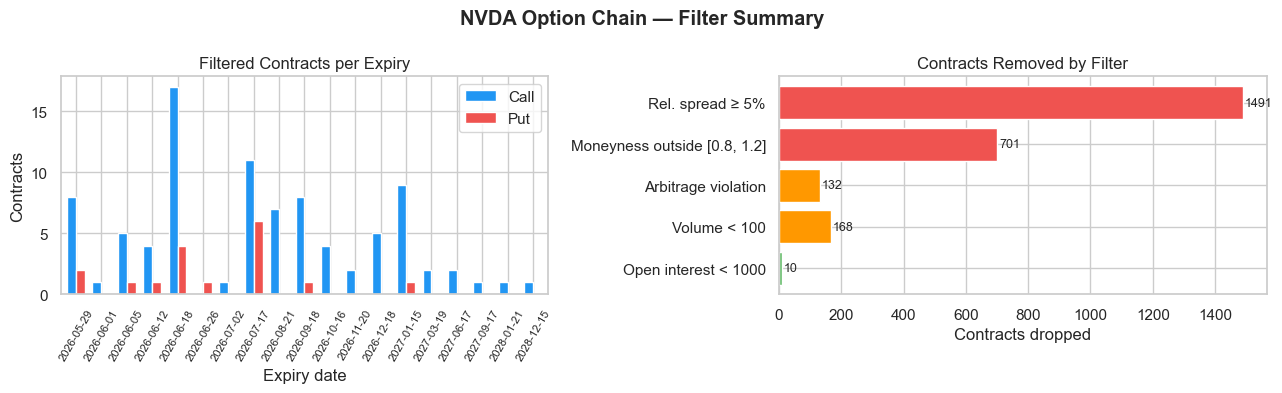

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'NVDA Option Chain — Filter Summary', fontweight='bold')

# Contracts per expiry (calls vs puts)
mat_counts = filtered_df.groupby(['maturity', 'type']).size().unstack(fill_value=0)
mat_counts.plot(kind='bar', ax=axes[0], color=['#2196F3', '#EF5350'], width=0.7, edgecolor='white')
axes[0].set_title('Filtered Contracts per Expiry')
axes[0].set_xlabel('Expiry date')
axes[0].set_ylabel('Contracts')
axes[0].tick_params(axis='x', rotation=60, labelsize=8)
axes[0].legend(['Call', 'Put'])

# Filter waterfall
reasons = list(filter_stats.keys())
counts  = list(filter_stats.values())
colors  = ['#EF5350' if c > 300 else '#FF9800' if c > 50 else '#66BB6A' for c in counts]
axes[1].barh(reasons[::-1], counts[::-1], color=colors[::-1], edgecolor='white')
axes[1].set_title('Contracts Removed by Filter')
axes[1].set_xlabel('Contracts dropped')
for i, v in enumerate(counts[::-1]):
    axes[1].text(v + 5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
#plt.savefig('filter_analysis.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 4 — Calibrate Heston Model

Two passes:
1. **European proxy** (~3 s) — analytical characteristic function (Cui et al. 2016 LM solver). Used as warm-start.
2. **PDE / C++ MCS ADI** (~60–90 s) — proper American early-exercise via Modified Craig-Sneyd ADI, unconditionally stable C++ backend.

Both passes use **maturity-matched SOFR/OIS rates** (not a flat scalar R).

In [292]:
from services.calibration_service import calibrate_option_chain
from services.pricing_service import HestonParameters

print('Pass 1 — European proxy (fast warm start)...')
res_eu, _ = calibrate_option_chain(
    filtered_df,
    rate_curve=rate_curve,
    american_method='european_proxy',
)
p_eu = res_eu.params
feller_eu = 2*p_eu.kappa*p_eu.theta - p_eu.sigma**2
print(f'  Done in {res_eu.runtime_seconds:.1f}s  |  Loss: {res_eu.loss:.4e}')
print(f'  v₀={p_eu.v0:.4f}  κ={p_eu.kappa:.4f}  θ={p_eu.theta:.4f}  σ={p_eu.sigma:.4f}  ρ={p_eu.rho:.4f}')
print(f'  Feller: {feller_eu:+.4f}  ({"\u2713" if feller_eu > 0 else "\u2717"})')

Pass 1 — European proxy (fast warm start)...
  Done in 2.3s  |  Loss: 3.8878e+00
  v₀=0.0507  κ=4.5575  θ=0.0806  σ=0.8573  ρ=-0.3601
  Feller: -0.0001  (✗)


In [293]:
Ns, Nv, Nt = 40, 20, 40

print('Pass 2 — PDE calibration (C++ MCS ADI backend)...')
print(f'  Contracts : {len(filtered_df):,}  |  PDE grid: Ns={Ns} Nv={Nv} Nt={Nt}')
print(f'  Warm start: EU proxy params')
print()

res_pde, cal_df = calibrate_option_chain(
    filtered_df,
    rate_curve=rate_curve,
    american_method='pde',
    initial_guess=p_eu,
    Ns=Ns, Nv=Nv, Nt=Nt,
)
p   = res_pde.params
feller = 2*p.kappa*p.theta - p.sigma**2

print(f'Calibration complete in {res_pde.runtime_seconds:.1f}s')
print()
print(f'  {"Parameter":<28} {"EU Proxy":>12} {"PDE (final)":>12}')
print(f'  {"─"*54}')
for name, v_eu, v_pde in [
    ('v₀  (initial variance)',  p_eu.v0,    p.v0),
    ('κ   (mean-reversion)',    p_eu.kappa, p.kappa),
    ('θ̄   (long-run variance)', p_eu.theta, p.theta),
    ('σ   (vol of vol)',        p_eu.sigma, p.sigma),
    ('ρ   (spot-vol corr)',     p_eu.rho,   p.rho),
]:
    print(f'  {name:<28} {v_eu:>12.6f} {v_pde:>12.6f}')
print(f'  {"─"*54}')
print(f'  {"Loss":<28} {res_eu.loss:>12.4e} {res_pde.loss:>12.4e}')
print()
print(f'  Feller 2κθ−σ²  : {feller:+.4f}  ({"satisfied ✓" if feller > 0 else "VIOLATED ✗"})')
print(f'  Init vol        : {p.v0**0.5*100:.1f}%')
print(f'  Long-run vol    : {p.theta**0.5*100:.1f}%')
print(f'  Loss reduction  : {(res_eu.loss - res_pde.loss)/res_eu.loss*100:.1f}% vs EU proxy')

Pass 2 — PDE calibration (C++ MCS ADI backend)...
  Contracts : 106  |  PDE grid: Ns=40 Nv=20 Nt=40
  Warm start: EU proxy params

Calibration complete in 47.5s

  Parameter                        EU Proxy  PDE (final)
  ──────────────────────────────────────────────────────
  v₀  (initial variance)           0.050684     0.069119
  κ   (mean-reversion)             4.557504     0.373769
  θ̄   (long-run variance)         0.080633     1.994342
  σ   (vol of vol)                 0.857337     1.000000
  ρ   (spot-vol corr)             -0.360136     0.056486
  ──────────────────────────────────────────────────────
  Loss                           3.8878e+00   1.5996e+03

  Feller 2κθ−σ²  : +0.4908  (satisfied ✓)
  Init vol        : 26.3%
  Long-run vol    : 141.2%
  Loss reduction  : -41044.0% vs EU proxy


---
## Step 5 — Price All Contracts

Price every filtered contract using the PDE-calibrated Heston parameters.  
Each contract uses its own maturity-matched SOFR/OIS rate from the curve.

In [294]:
from services.pricing_service import price_option_frame

print(f'Pricing {len(filtered_df):,} contracts (PDE / C++ backend, maturity-matched rates)...')
prices = price_option_frame(
    filtered_df,
    rate_curve=rate_curve,
    heston_params=res_pde,
    Ns=Ns, Nv=Nv, Nt=Nt,
    american_method='pde',
)

print(f'  Priced OK : {prices.notna().sum():,}')
print(f'  Failed    : {prices.isna().sum():,}')
print(f'  Range     : ${prices.dropna().min():.4f} – ${prices.dropna().max():.4f}')

Pricing 106 contracts (PDE / C++ backend, maturity-matched rates)...
  Priced OK : 106
  Failed    : 0
  Range     : $0.0406 – $58.9361


---
## Step 6 — Validate Prices

Sanity checks applied before accepting results:
1. All prices ≥ 0
2. All prices ≥ intrinsic value (no early-exercise arbitrage)
3. No blown-up values (|price| > $1,000,000)
4. Compare to market mid-price (MAE, relative error, bid-ask coverage)

In [295]:
df = filtered_df.copy()
df['model_price'] = prices

# ── basic checks ──────────────────────────────────────────────────────────
assert (df['model_price'].dropna() >= 0).all(), 'FAIL: negative prices'
print('✓  All prices non-negative')

df['intrinsic'] = np.where(
    df['type'] == 'call',
    np.maximum(df['spot'] - df['strike'], 0.0),
    np.maximum(df['strike'] - df['spot'], 0.0),
)
violations = df[df['model_price'] < df['intrinsic'] - 0.01]
print(f'✓  Intrinsic violations : {len(violations)}')

blown = df[df['model_price'].abs() > 1e6]
print(f'✓  Blown-up contracts   : {len(blown)}')

# ── price accuracy ────────────────────────────────────────────────────────
df['price_error']   = df['model_price'] - df['mid_price']
df['abs_error']     = df['price_error'].abs()
df['rel_error']     = df['price_error'] / df['mid_price']
df['within_spread'] = (df['model_price'] >= df['bid']) & (df['model_price'] <= df['ask'])

print()
print('Pricing accuracy:')
print(f'  MAE                   : ${df["abs_error"].mean():.4f}')
print(f'  Median abs error      : ${df["abs_error"].median():.4f}')
print(f'  Mean relative error   : {df["rel_error"].abs().mean()*100:.2f}%')
print(f'  Within bid-ask spread : {df["within_spread"].sum()} / {len(df)}  ({df["within_spread"].mean()*100:.1f}%)')

✓  All prices non-negative
✓  Intrinsic violations : 0
✓  Blown-up contracts   : 0

Pricing accuracy:
  MAE                   : $3.3884
  Median abs error      : $2.2652
  Mean relative error   : 46.94%
  Within bid-ask spread : 9 / 106  (8.5%)


In [296]:
from calibration.implied_vol import implied_volatility

def row_iv(row, price_col):
    price = row.get(price_col)
    if pd.isna(price) or price <= 0:
        return np.nan
    try:
        return implied_volatility(
            price, row['spot'], row['strike'],
            float(row.get('r', R)),   # per-row SOFR rate from df["r"]
            row['T'], row['type'],
            float(row.get('q', 0.0)), # per-row dividend yield from df["q"]
        )
    except Exception:
        return np.nan

df['market_iv'] = df.apply(row_iv, axis=1, args=('mid_price',))
df['model_iv']  = df.apply(row_iv, axis=1, args=('model_price',))
df['iv_error']  = df['model_iv'] - df['market_iv']

print('Implied Volatility accuracy:')
print(f'  Market IV  — mean: {df["market_iv"].mean()*100:.1f}%   std: {df["market_iv"].std()*100:.1f}%')
print(f'  Model  IV  — mean: {df["model_iv"].mean()*100:.1f}%   std: {df["model_iv"].std()*100:.1f}%')
print()
print(f'  Mean |IV error|  : {df["iv_error"].abs().mean()*100:.2f} vol points')
print(f'  Max  |IV error|  : {df["iv_error"].abs().max()*100:.2f} vol points')


Implied Volatility accuracy:
  Market IV  — mean: 49.4%   std: 39.4%
  Model  IV  — mean: 46.3%   std: 33.6%

  Mean |IV error|  : 9.54 vol points
  Max  |IV error|  : 67.92 vol points


In [297]:
df['T_bucket'] = pd.cut(df['T'], bins=[0, 0.1, 0.5, 1.0, 3.0],
                         labels=['< 1M', '1–6M', '6M–1Y', '1–3Y'])

summary = df.groupby('T_bucket', observed=True).agg(
    N           = ('model_price', 'count'),
    MAE         = ('abs_error',   'mean'),
    MRE         = ('rel_error',   lambda x: x.abs().mean()),
    within_ba   = ('within_spread', 'mean'),
    iv_err_mean = ('iv_error',    lambda x: x.abs().mean()),
).round(4)

summary['MAE']         = summary['MAE'].map('${:.4f}'.format)
summary['MRE']         = (summary['MRE'] * 100).map('{:.2f}%'.format)
summary['within_ba']   = (summary['within_ba'] * 100).map('{:.1f}%'.format)
summary['iv_err_mean'] = (summary['iv_err_mean'] * 100).map('{:.2f} vpts'.format)
summary.columns = ['N', 'MAE', 'Mean Rel Err', 'Within B/A', 'Mean IV Err']

print('Accuracy by maturity bucket:')
print(summary.to_string())

Accuracy by maturity bucket:
           N      MAE Mean Rel Err Within B/A Mean IV Err
T_bucket                                                 
< 1M      45  $1.4108       38.84%      17.8%  11.23 vpts
1–6M      39  $4.1107       58.08%       2.6%   8.44 vpts
6M–1Y     17  $5.9151       50.76%       0.0%   7.86 vpts
1–3Y       5  $6.9630       19.91%       0.0%   8.64 vpts


---
## Step 7 — Visualize Calibration Quality

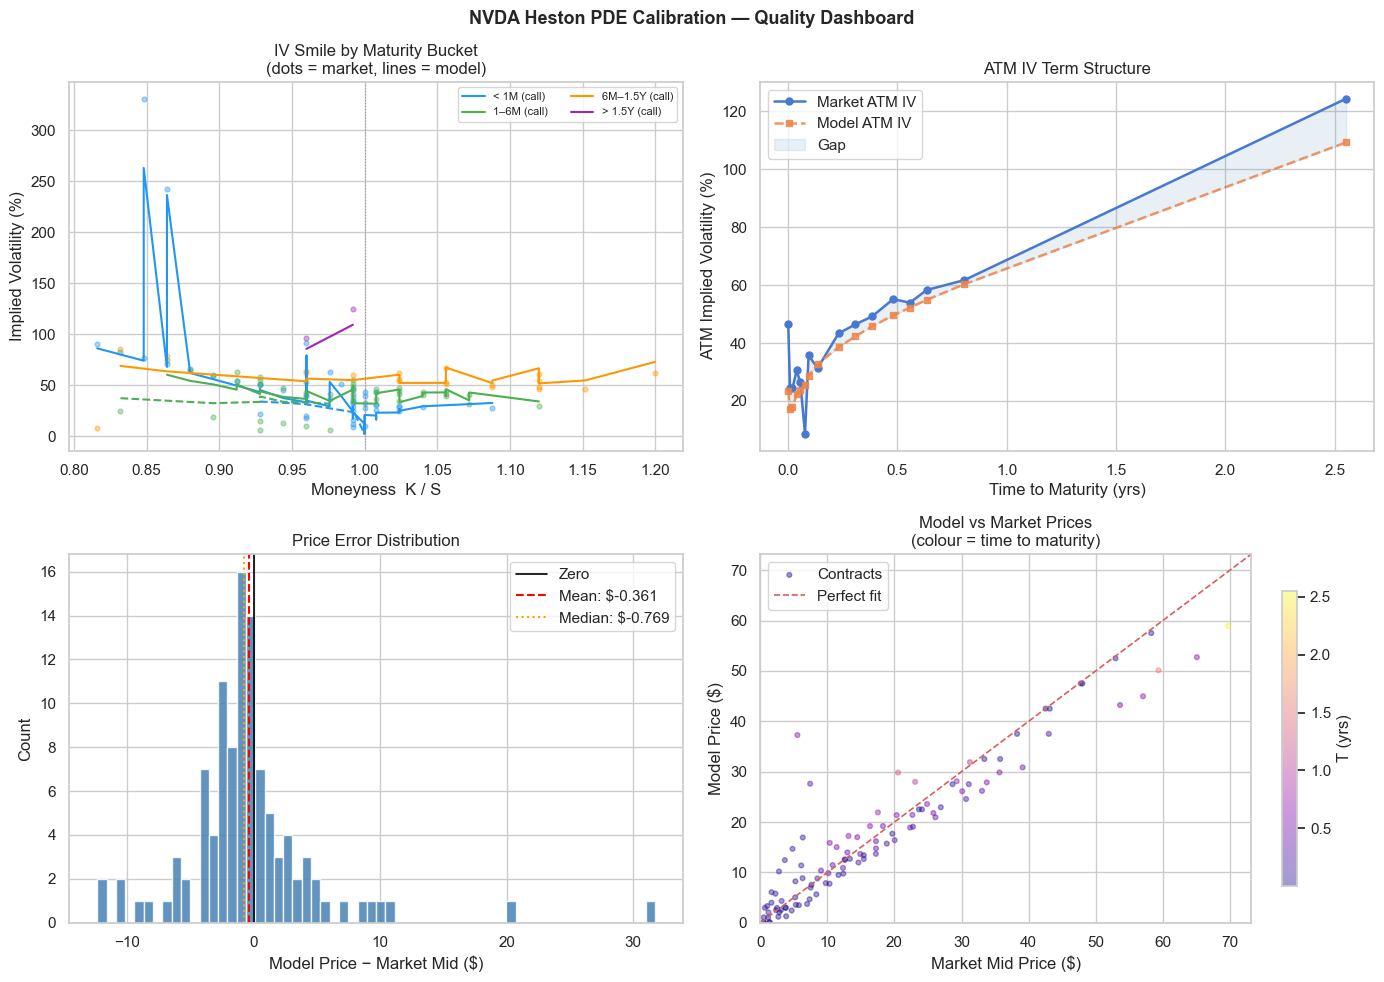

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'NVDA Heston PDE Calibration — Quality Dashboard', fontweight='bold', fontsize=13)

# ── 1. IV smile by maturity bucket ───────────────────────────────────────
ax = axes[0, 0]
T_buckets = [
    (0,    0.1,  '< 1M',     '#2196F3'),
    (0.1,  0.5,  '1–6M',     '#4CAF50'),
    (0.5,  1.5,  '6M–1.5Y',  '#FF9800'),
    (1.5,  5.0,  '> 1.5Y',   '#9C27B0'),
]
for T_lo, T_hi, label, color in T_buckets:
    sub = df[(df['T'] >= T_lo) & (df['T'] < T_hi) & df['market_iv'].notna() & df['model_iv'].notna()]
    if sub.empty:
        continue
    ax.scatter(sub['moneyness'], sub['market_iv'] * 100, s=12, alpha=0.4, color=color)
    for mtype, ls in [('call', '-'), ('put', '--')]:
        s2 = sub[sub['type'] == mtype].sort_values('moneyness')
        if not s2.empty:
            ax.plot(s2['moneyness'], s2['model_iv'] * 100, ls=ls, color=color,
                    lw=1.5, label=f'{label} ({mtype})' if ls == '-' else None)
ax.axvline(1.0, color='gray', lw=0.8, ls=':', alpha=0.7)
ax.set_xlabel('Moneyness  K / S')
ax.set_ylabel('Implied Volatility (%)')
ax.set_title('IV Smile by Maturity Bucket\n(dots = market, lines = model)')
ax.legend(fontsize=8, ncol=2)

# ── 2. ATM IV term structure ─────────────────────────────────────────────
ax = axes[0, 1]
atm = df[df['atm_distance'] < 0.03].copy()
atm_mkt = atm.groupby('T')['market_iv'].mean() * 100
atm_mdl = atm.groupby('T')['model_iv'].mean()  * 100
ax.plot(atm_mkt.index, atm_mkt.values, 'o-',  lw=1.8, ms=5, label='Market ATM IV')
ax.plot(atm_mdl.index, atm_mdl.values, 's--', lw=1.8, ms=5, label='Model ATM IV',  alpha=0.85)
ax.fill_between(atm_mkt.index, atm_mkt.values,
                atm_mdl.reindex(atm_mkt.index).ffill(),
                alpha=0.12, color='steelblue', label='Gap')
ax.set_xlabel('Time to Maturity (yrs)')
ax.set_ylabel('ATM Implied Volatility (%)')
ax.set_title('ATM IV Term Structure')
ax.legend()

# ── 3. Price error distribution ──────────────────────────────────────────
ax = axes[1, 0]
err = df['price_error'].dropna()
ax.hist(err, bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0,           color='black', lw=1.2, ls='-',  label='Zero')
ax.axvline(err.mean(),  color='red',   lw=1.5, ls='--', label=f'Mean: ${err.mean():.3f}')
ax.axvline(err.median(),color='orange',lw=1.5, ls=':',  label=f'Median: ${err.median():.3f}')
ax.set_xlabel('Model Price − Market Mid ($)')
ax.set_ylabel('Count')
ax.set_title('Price Error Distribution')
ax.legend()

# ── 4. Model vs market price scatter ─────────────────────────────────────
ax = axes[1, 1]
scatter = ax.scatter(df['mid_price'], df['model_price'], s=12, alpha=0.4,
                     c=df['T'], cmap='plasma', label='Contracts')
lim = max(df['mid_price'].max(), df['model_price'].max()) * 1.05
ax.plot([0, lim], [0, lim], 'r--', lw=1.2, label='Perfect fit')
ax.set_xlabel('Market Mid Price ($)')
ax.set_ylabel('Model Price ($)')
ax.set_title('Model vs Market Prices\n(colour = time to maturity)')
ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
plt.colorbar(scatter, ax=ax, label='T (yrs)', shrink=0.8)
ax.legend()

plt.tight_layout()
#plt.savefig('calibration_quality.png', dpi=120, bbox_inches='tight')
plt.show()


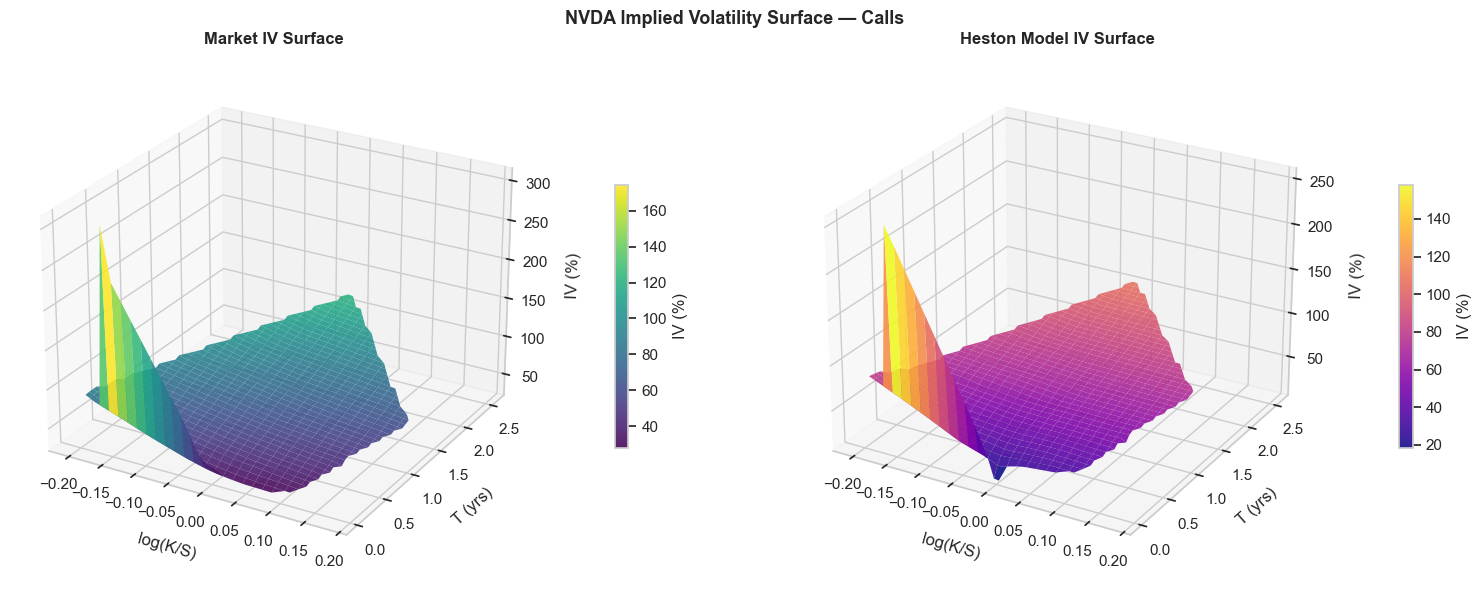

In [ ]:
# ── IV Surface (Market vs Model) ─────────────────────────────────────────
surf = df[(df['type'] == 'call') & df['market_iv'].notna() & df['model_iv'].notna()
          & (df['market_iv'] > 0.05)].copy()
surf['log_m'] = np.log(surf['moneyness'])

lm_grid = np.linspace(surf['log_m'].min(), surf['log_m'].max(), 55)
T_grid  = np.linspace(surf['T'].min(),     surf['T'].max(),     45)
LM, TT  = np.meshgrid(lm_grid, T_grid)

Z_mkt = griddata((surf['log_m'], surf['T']), surf['market_iv'] * 100, (LM, TT), method='linear')
Z_mdl = griddata((surf['log_m'], surf['T']), surf['model_iv']  * 100, (LM, TT), method='linear')

fig = plt.figure(figsize=(16, 6))
fig.suptitle('NVDA Implied Volatility Surface — Calls', fontweight='bold', fontsize=13)

for idx, (Z, title, cmap) in enumerate([
    (Z_mkt, 'Market IV Surface',       'viridis'),
    (Z_mdl, 'Heston Model IV Surface', 'plasma'),
], 1):
    ax = fig.add_subplot(1, 2, idx, projection='3d')
    surf_plot = ax.plot_surface(LM, TT, Z, cmap=cmap, alpha=0.88,
                                 linewidth=0, antialiased=True)
    ax.set_xlabel('log(K/S)',  labelpad=8)
    ax.set_ylabel('T (yrs)',   labelpad=8)
    ax.set_zlabel('IV (%)',    labelpad=8)
    ax.set_title(title, fontweight='bold')
    plt.colorbar(surf_plot, ax=ax, shrink=0.5, pad=0.1, label='IV (%)')
    ax.view_init(elev=25, azim=-60)

plt.tight_layout()
#plt.savefig('iv_surface.png', dpi=120, bbox_inches='tight')
plt.show()

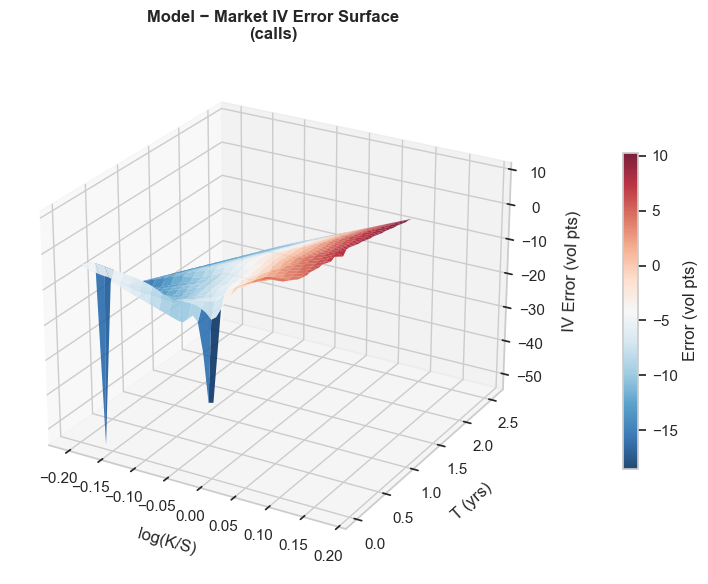

In [ ]:
# ── IV Error Surface ──────────────────────────────────────────────────────
Z_err = Z_mdl - Z_mkt

fig = plt.figure(figsize=(9, 6))
ax  = fig.add_subplot(111, projection='3d')
surf_plot = ax.plot_surface(LM, TT, Z_err, cmap='RdBu_r', alpha=0.88,
                             linewidth=0, antialiased=True)
ax.set_xlabel('log(K/S)', labelpad=8)
ax.set_ylabel('T (yrs)',  labelpad=8)
ax.set_zlabel('IV Error (vol pts)', labelpad=8)
ax.set_title('Model − Market IV Error Surface\n(calls)', fontweight='bold')
plt.colorbar(surf_plot, ax=ax, shrink=0.6, pad=0.1, label='Error (vol pts)')
ax.view_init(elev=25, azim=-60)

plt.tight_layout()
#plt.savefig('iv_error_surface.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 8 — Put-Call Parity Check

For American options the modified parity inequality holds: `C − P ≤ S·e^{−qT} − K·e^{−rT}`.  
We check the **model** call-put difference and compare to the European lower bound.  
Large systematic deviations signal a model consistency issue.

In [301]:
results = []
for mat, grp in df.groupby('maturity'):
    calls = grp[grp['type'] == 'call'].drop_duplicates('strike').set_index('strike')
    puts  = grp[grp['type'] == 'put'].drop_duplicates('strike').set_index('strike')
    common = calls.index.intersection(puts.index)
    if common.empty:
        continue
    par = pd.DataFrame({
        'maturity'  : mat,
        'call_price': calls.loc[common, 'model_price'],
        'put_price' : puts.loc[common,  'model_price'],
        'spot'      : calls.loc[common, 'spot'],
        'T'         : calls.loc[common, 'T'],
        'r_t'       : calls.loc[common, 'r'],
        'q_t'       : calls.loc[common, 'q'],
    })
    par['lhs']          = par['call_price'] - par['put_price']
    par['rhs']          = par['spot'] * np.exp(-par['q_t'] * par['T']) - common * np.exp(-par['r_t'] * par['T'])
    par['parity_error'] = par['lhs'] - par['rhs']
    results.append(par)

parity = pd.concat(results)
print('Put-Call Parity  (model prices, per-row maturity-matched r and q):')
print(parity[['lhs', 'rhs', 'parity_error']].describe().round(4))
print(f'\nMean parity error : {parity["parity_error"].mean():.4f}')
print(f'Std  parity error : {parity["parity_error"].std():.4f}')
print(f'Max |parity error|: {parity["parity_error"].abs().max():.4f}')


Put-Call Parity  (model prices, per-row maturity-matched r and q):
          lhs     rhs  parity_error
count 13.0000 13.0000       13.0000
mean   4.8678  3.1011        1.7666
std    9.5073  8.2505        2.1180
min   -5.1111 -6.1323        0.0001
25%   -1.4172 -2.8874        0.2714
50%    1.0331  0.5612        1.1583
75%    7.6434  7.0927        2.1267
max   26.4383 19.4547        6.9836

Mean parity error : 1.7666
Std  parity error : 2.1180
Max |parity error|: 6.9836


---
## Step 9 — Mispricing Analysis

Contracts where the Heston model price diverges significantly from the market mid-price.  
Large positive errors (model > market) → model sees these as cheap relative to its parameters.  
Large negative errors (market > model) → model sees these as expensive.

In [302]:
df['mispricing_$']   = df['model_price'] - df['mid_price']
df['mispricing_%']   = df['mispricing_$'] / df['mid_price'] * 100

SHOW_COLS = ['type', 'maturity', 'strike', 'T', 'mid_price', 'model_price',
             'mispricing_$', 'mispricing_%', 'market_iv', 'model_iv']

print('Top 10 — Model OVER-PRICED  (model > market, potential market buys)')
print('─' * 110)
over = df.nlargest(10, 'mispricing_$')[SHOW_COLS]
print(over.to_string(index=False))

print()
print('Top 10 — Model UNDER-PRICED (market > model, potential market sells)')
print('─' * 110)
under = df.nsmallest(10, 'mispricing_$')[SHOW_COLS]
print(under.to_string(index=False))

Top 10 — Model OVER-PRICED  (model > market, potential market buys)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────
type   maturity   strike      T  mid_price  model_price  mispricing_$  mispricing_%  market_iv  model_iv
 put 2027-01-15 255.0000 0.6336     5.5250      37.2627       31.7377      574.4375     0.0785    0.4821
 put 2026-09-18 290.0000 0.3076     7.4250      27.5983       20.1733      271.6942     0.0565    0.3897
 put 2026-07-17 305.0000 0.1350     6.3250      16.9253       10.6003      167.5934     0.0640    0.3188
 put 2026-07-17 300.0000 0.1350     4.8000      14.6808        9.8808      205.8500     0.1046    0.3308
call 2027-09-17 375.0000 1.3048    20.5250      29.8150        9.2900       45.2619     0.6178    0.7286
 put 2026-07-17 295.0000 0.1350     3.6500      12.4363        8.7863      240.7210     0.1298    0.3367
 put 2026-07-17 290.0000 0.1350     2.7800      10.1918        7.4118      266.6128   

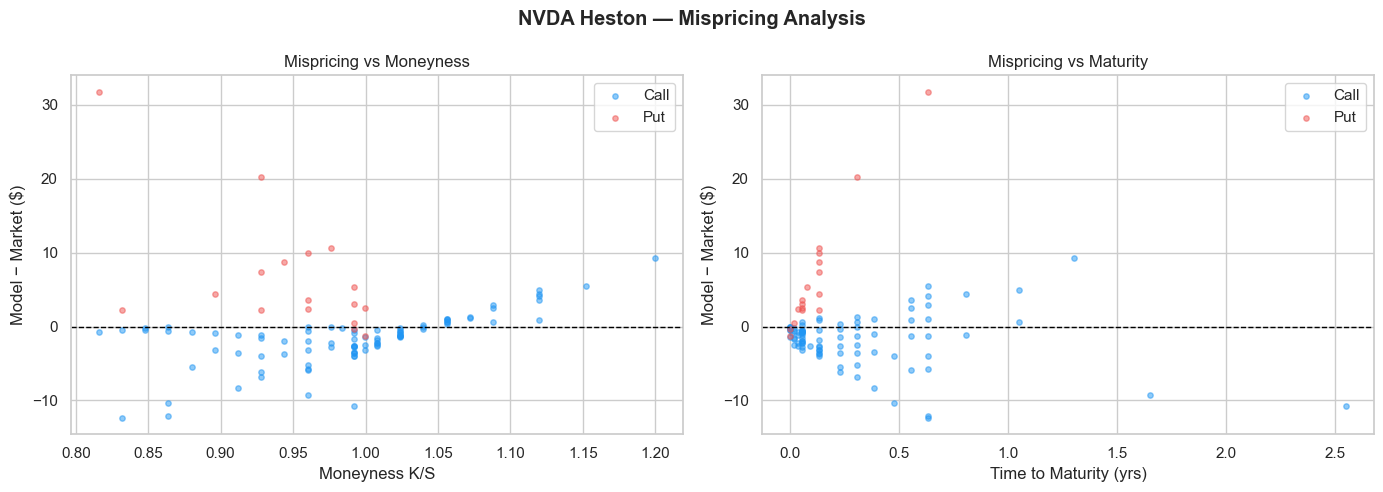

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('NVDA Heston — Mispricing Analysis', fontweight='bold')

# Mispricing vs moneyness (calls and puts)
ax = axes[0]
for mtype, color in [('call', '#2196F3'), ('put', '#EF5350')]:
    sub = df[df['type'] == mtype]
    ax.scatter(sub['moneyness'], sub['mispricing_$'], s=15, alpha=0.5,
               color=color, label=mtype.capitalize())
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Moneyness K/S')
ax.set_ylabel('Model − Market ($)')
ax.set_title('Mispricing vs Moneyness')
ax.legend()

# Mispricing vs maturity
ax = axes[1]
for mtype, color in [('call', '#2196F3'), ('put', '#EF5350')]:
    sub = df[df['type'] == mtype]
    ax.scatter(sub['T'], sub['mispricing_$'], s=15, alpha=0.5,
               color=color, label=mtype.capitalize())
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xlabel('Time to Maturity (yrs)')
ax.set_ylabel('Model − Market ($)')
ax.set_title('Mispricing vs Maturity')
ax.legend()

plt.tight_layout()
#plt.savefig('mispricing.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Summary

In [304]:
print('=' * 60)
print('  NVDA HESTON PRICING ENGINE — PIPELINE SUMMARY')
print('=' * 60)
print()
print(f'  Market data')
print(f'    Ticker               : {TICKER}')
print(f'    Spot                 : ${SPOT:.2f}')
for tkr, q_val in filtered_df.groupby('ticker')['q'].first().items():
    print(f'    Dividend yield {tkr:<6} : {q_val*100:.4f}%  (from yfinance, per-row in df["q"])')
print()
print(f'  Interest rate')
print(f'    Methodology          : Per-row maturity-matched SOFR/OIS (df["r"])')
print(f'    3M SOFR (scalar R)   : {R*100:.3f}%  (display/fallback only)')
print(f'    Curve                : {curve_summary(rate_curve)}')
print(f'    r range in df        : {filtered_df["r"].min()*100:.3f}% – {filtered_df["r"].max()*100:.3f}%')
print()
print(f'  Filtering')
print(f'    Raw contracts        : {n_raw:,}')
print(f'    After filters        : {n_filt:,}  ({n_filt/n_raw*100:.1f}%)')
print(f'    Expiries             : {filtered_df["maturity"].nunique()}')
print()
print(f'  Calibration  (PDE / C++ MCS ADI)')
print(f'    v₀                   : {p.v0:.6f}  → init vol {p.v0**0.5*100:.1f}%')
print(f'    κ  (mean reversion)  : {p.kappa:.4f}')
print(f'    θ̄  (long-run var)    : {p.theta:.6f}  → LR vol {p.theta**0.5*100:.1f}%')
print(f'    σ  (vol of vol)      : {p.sigma:.4f}')
print(f'    ρ  (spot-vol corr)   : {p.rho:.4f}')
print(f'    Feller 2κθ−σ²        : {feller:+.4f}  ({"satisfied ✓" if feller > 0 else "VIOLATED ✗"})')
print(f'    Loss                 : {res_pde.loss:.4e}')
print(f'    Runtime              : {res_pde.runtime_seconds:.1f}s')
print()
print(f'  Pricing accuracy')
print(f'    MAE                  : ${df["abs_error"].mean():.4f}')
print(f'    Mean rel error       : {df["rel_error"].abs().mean()*100:.2f}%')
print(f'    Within bid-ask       : {df["within_spread"].sum()} / {len(df)}  ({df["within_spread"].mean()*100:.1f}%)')
print(f'    Mean IV error        : {df["iv_error"].abs().mean()*100:.2f} vol pts')
print('=' * 60)


  NVDA HESTON PRICING ENGINE — PIPELINE SUMMARY

  Market data
    Ticker               : AAPL
    Spot                 : $312.51
    Dividend yield AAPL   : 35.0000%  (from yfinance, per-row in df["q"])

  Interest rate
    Methodology          : Per-row maturity-matched SOFR/OIS (df["r"])
    3M SOFR (scalar R)   : 3.645%  (display/fallback only)
    Curve                : 3M: 3.64%  |  6M: 3.71%  |  5Y: 4.16%  |  10Y: 4.45%
    r range in df        : 3.592% – 4.112%

  Filtering
    Raw contracts        : 2,608
    After filters        : 106  (4.1%)
    Expiries             : 19

  Calibration  (PDE / C++ MCS ADI)
    v₀                   : 0.069119  → init vol 26.3%
    κ  (mean reversion)  : 0.3738
    θ̄  (long-run var)    : 1.994342  → LR vol 141.2%
    σ  (vol of vol)      : 1.0000
    ρ  (spot-vol corr)   : 0.0565
    Feller 2κθ−σ²        : +0.4908  (satisfied ✓)
    Loss                 : 1.5996e+03
    Runtime              : 47.5s

  Pricing accuracy
    MAE                 